<div style="background: linear-gradient(135deg, #2E86AB 0%, #A23B72 100%); 
            padding: 40px; 
            border-radius: 10px; 
            text-align: center; 
            color: white;">

<h1 style="font-size: 48px; margin: 0; font-weight: bold;">CAR's PRICE ANALYSIS</h1>
<h3 style="font-size: 20px; margin-top: 10px; font-weight: normal;">Using Data Analytics</h3>
<p style="font-size: 16px; margin-top: 15px;">
    AIM: To analyze Car selling price using Visualization models in Python 
</p>

</div>

## **INTRODUCTION**

This project focuses on analyzing car price data to build predictive models using Python libraries such as Pandas, NumPy, Matplotlib... The analysis includes data cleaning, exploratory data analysis and model evaluation to identify key factors that influence car prices.

Objectives:

1.Importing Libraries and DataObjective: To import necessary Python libraries like Pandas, NumPy, Matplotlib, Seaborn and load the car price dataset into a DataFrame for analysis.

2.Cleaning and PreprocessingObjective: To identify and handle missing values, remove duplicates, correct data types, and standardize column formats to ensure data quality.

3.VisualisationsObjective: To represent data patterns graphically for better interpretation of trends, distributions, and correlations.

4.Without Visualisation CodeObjective: To extract key insights using statistical methods like value_counts(), mean(), corr() instead of relying solely on plots.

5.Overall Project Objective: To perform exploratory data analysis on used car data and identify the most significant factors affecting selling price, preparing the dataset for price prediction modeling.


## **Importing Libraries**

In [39]:
# Core Data Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

<div style="border-top: 3px solid #A23B72; padding-top: 15px; margin-top: 20px;">
<h2 style="color: #A23B72; text-decoration: underline; font-weight: bold;">
    Data Loading & Initial Overview
</h2>
</div>

In [40]:
df = pd.read_csv(r'Car_Price_Prediction_DataSet.csv')

## **Dataset Overview**

The dataset used for this Car Price Prediction project each record represents a single car listing and includes key attributes such as car name, manufacturing year, kilometers driven, fuel type, seller type, transmission, ownership history, mileage in kmpl, engine capacity in CC, max power in bhp, and number of seats. The target variable for prediction is `selling_price`. The dataset is a mix of numerical and categorical variables, with numerical columns like `year`, `km_driven`, `mileage_kmpl`, `engine`, and `max_power` capturing car specifications, and categorical columns like `fuel`, `seller_type`, `transmission`, and `owner` capturing qualitative details. Preliminary inspection shows some missing values in the `mileage_kmpl`, `engine`, `max_power`, and `seats` columns, which will require treatment during data cleaning. This dataset is suitable for regression modeling to predict used car selling prices based on historical listings.

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 100%;">
  <thead style="background-color: #f2f2f2;">
    <tr>
      <th>Column Name</th>
      <th>Description</th>
      <th>Data Type</th>
      <th>Notes for Modeling</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>name</b></td>
      <td>Full car model name, e.g. "Maruti Swift VXI"</td>
      <td>Object / Text</td>
      <td>Extract brand for better features. High cardinality.</td>
    </tr>
    <tr>
      <td><b>year</b></td>
      <td>Manufacturing year of the car</td>
      <td>Integer</td>
      <td>Convert to car_age = 2024 - year for better prediction</td>
    </tr>
    <tr>
      <td><b>selling_price</b></td>
      <td>Target variable: Price at which car was sold in INR</td>
      <td>Float</td>
      <td>This is what you’re predicting</td>
    </tr>
    <tr>
      <td><b>km_driven</b></td>
      <td>Total kilometers the car has run</td>
      <td>Integer</td>
      <td>Higher km = lower price. Check for outliers</td>
    </tr>
    <tr>
      <td><b>fuel</b></td>
      <td>Type of fuel: Petrol, Diesel, CNG, LPG, Electric</td>
      <td>Object / Categorical</td>
      <td>Diesel holds value better. Use one-hot encoding</td>
    </tr>
    <tr>
      <td><b>seller_type</b></td>
      <td>Who sold it: Dealer, Individual, Trustmark Dealer</td>
      <td>Object / Categorical</td>
      <td>Dealer cars often priced higher</td>
    </tr>
    <tr>
      <td><b>transmission</b></td>
      <td>Manual or Automatic transmission</td>
      <td>Object / Categorical</td>
      <td>Automatic usually costs more. Binary encode</td>
    </tr>
    <tr>
      <td><b>owner</b></td>
      <td>Number of previous owners: First, Second, Third, Fourth & Above</td>
      <td>Object / Categorical</td>
      <td>More owners = lower price. Treat as ordinal</td>
    </tr>
    <tr>
      <td><b>mileagekm_ltr_kg</b></td>
      <td>Fuel efficiency in km per liter or kg</td>
      <td>Float</td>
      <td>Higher mileage = higher demand. Needs unit cleaning</td>
    </tr>
    <tr>
      <td><b>engine</b></td>
      <td>Engine displacement in CC</td>
      <td>Integer</td>
      <td>Bigger engine = higher price. Has some missing values</td>
    </tr>
    <tr>
      <td><b>max_power</b></td>
      <td>Max power in bhp, e.g. "83.1 bhp"</td>
      <td>Object / Text</td>
      <td>Extract numeric value. Higher power = higher price</td>
    </tr>
    <tr>
      <td><b>seats</b></td>
      <td>Number of seats in the car</td>
      <td>Integer</td>
      <td>Mostly 5 or 7. Low predictive power</td>
    </tr>
  </tbody>
</table>

In [41]:
print(f"Shape: {df.shape}") 

Shape: (8128, 12)


In [42]:
print(f"\nColumn names:\n{list(df.columns)}")


Column names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']


In [43]:
print(f"\nFirst 5 rows:")
print(df.head())


First 5 rows:
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner  mileage(km/ltr/kg)  engine  \
0  Individual       Manual   First Owner               23.40  1248.0   
1  Individual       Manual  Second Owner               21.14  1498.0   
2  Individual       Manual   Third Owner               17.70  1497.0   
3  Individual       Manual   First Owner               23.00  1396.0   
4  Individual       Manual   First Owner               16.10  1298.0   

  max_power  seats  
0        74    5.0  
1    103.52    5.0  
2        78    5.0  
3        90    5.

In [44]:
## Statistical Summary
print(df.describe())

              year  selling_price     km_driven  mileage(km/ltr/kg)  \
count  8128.000000   8.128000e+03  8.128000e+03         7907.000000   
mean   2013.804011   6.382718e+05  6.981951e+04           19.418783   
std       4.044249   8.062534e+05  5.655055e+04            4.037145   
min    1983.000000   2.999900e+04  1.000000e+00            0.000000   
25%    2011.000000   2.549990e+05  3.500000e+04           16.780000   
50%    2015.000000   4.500000e+05  6.000000e+04           19.300000   
75%    2017.000000   6.750000e+05  9.800000e+04           22.320000   
max    2020.000000   1.000000e+07  2.360457e+06           42.000000   

            engine        seats  
count  7907.000000  7907.000000  
mean   1458.625016     5.416719  
std     503.916303     0.959588  
min     624.000000     2.000000  
25%    1197.000000     5.000000  
50%    1248.000000     5.000000  
75%    1582.000000     5.000000  
max    3604.000000    14.000000  


In [45]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB
None


In [46]:
print(f"\nData types:")
print(df.dtypes)


Data types:
name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
mileage(km/ltr/kg)    float64
engine                float64
max_power              object
seats                 float64
dtype: object


In [47]:
print(f"\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64


<div style="border-top: 3px solid #A23B72; padding-top: 15px; margin-top: 20px;">
<h2 style="color: #A23B72; text-decoration: underline; font-weight: bold;">
    Data Cleaning-Duplicates & Fixing Missing Value
</h2>
</div>

In [48]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 1202


In [49]:
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")
print("Duplicates removed.")

Shape after dropping duplicates: (6926, 12)
Duplicates removed.


In [50]:
df.rename(columns=str.upper, inplace=True)

print(df.columns.tolist())

['NAME', 'YEAR', 'SELLING_PRICE', 'KM_DRIVEN', 'FUEL', 'SELLER_TYPE', 'TRANSMISSION', 'OWNER', 'MILEAGE(KM/LTR/KG)', 'ENGINE', 'MAX_POWER', 'SEATS']


Missing Values - fill with mean

In [51]:
df['MILEAGE(KM/LTR/KG)'] = df['MILEAGE(KM/LTR/KG)'].astype(str).str.extract(r'(\d+\.?\d*)')[0]
df['MILEAGE(KM/LTR/KG)'] = pd.to_numeric(df['MILEAGE(KM/LTR/KG)'], errors='coerce')

mean_mileage = df['MILEAGE(KM/LTR/KG)'].mean()
df['MILEAGE(KM/LTR/KG)'] = df['MILEAGE(KM/LTR/KG)'].fillna(mean_mileage)
print(f"MILEAGE filled with mean: {mean_mileage:.2f}")

MILEAGE filled with mean: 19.47


In [52]:
df['ENGINE'] = df['ENGINE'].astype(str).str.extract(r'(\d+\.?\d*)')[0]
df['ENGINE'] = pd.to_numeric(df['ENGINE'], errors='coerce')

mean_engine = df['ENGINE'].mean()
df['ENGINE'] = df['ENGINE'].fillna(mean_engine)
print(f"ENGINE filled with mean: {mean_engine:.2f}")

ENGINE filled with mean: 1430.89


In [53]:
df['MAX_POWER'] = df['MAX_POWER'].astype(str).str.extract(r'(\d+\.?\d*)')[0]
df['MAX_POWER'] = pd.to_numeric(df['MAX_POWER'], errors='coerce')

mean_power = df['MAX_POWER'].mean()
df['MAX_POWER'] = df['MAX_POWER'].fillna(mean_power)
print(f"MAX_POWER filled with mean: {mean_power:.2f}")

MAX_POWER filled with mean: 87.73


In [54]:
df['SEATS'] = pd.to_numeric(df['SEATS'], errors='coerce')
mean_seats = df['SEATS'].mean()

df['SEATS'] = df['SEATS'].fillna(mean_seats)
print(f"SEATS filled with mean: {mean_seats:.2f}")

SEATS filled with mean: 5.43


In [55]:
print(df.isnull().sum())

NAME                  0
YEAR                  0
SELLING_PRICE         0
KM_DRIVEN             0
FUEL                  0
SELLER_TYPE           0
TRANSMISSION          0
OWNER                 0
MILEAGE(KM/LTR/KG)    0
ENGINE                0
MAX_POWER             0
SEATS                 0
dtype: int64


## **Outlier Detection & BOX Plot**
Outliers are data points that sit way outside the normal range of your dataset using IQR(Interquartile Range) – they don’t follow the same pattern as most other values.

In [56]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_counts = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

    print(f"{col}: {len(outliers)} outliers")

YEAR: 77 outliers
SELLING_PRICE: 328 outliers
KM_DRIVEN: 167 outliers
MILEAGE(KM/LTR/KG): 23 outliers
ENGINE: 1207 outliers
MAX_POWER: 374 outliers
SEATS: 1672 outliers


In [57]:
total_outliers = sum(outlier_counts.values())
print(f"\nTotal outliers across all numeric columns: {total_outliers}")


Total outliers across all numeric columns: 3848


In [58]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

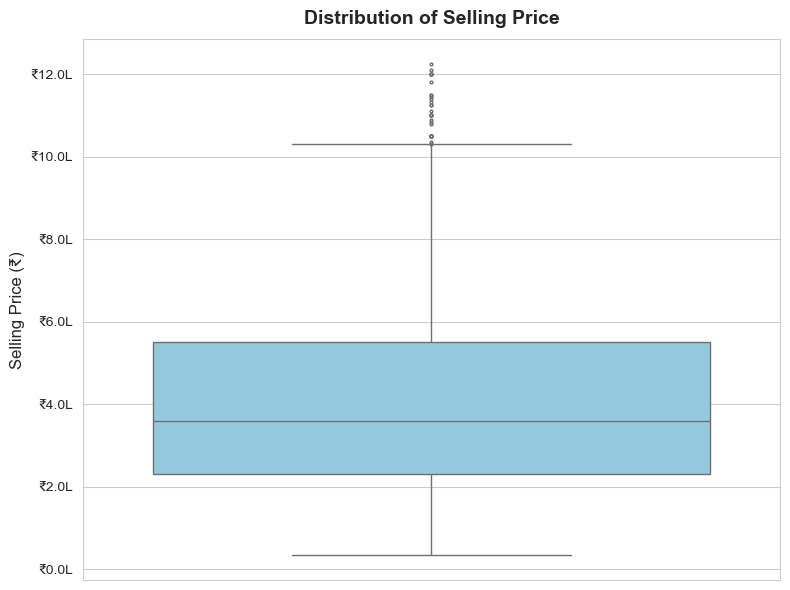

In [59]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

sns.boxplot(y=df['SELLING_PRICE'], color='skyblue', fliersize=2)

plt.title('Distribution of Selling Price', fontsize=14, fontweight='bold', pad=11)
plt.ylabel('Selling Price (₹)', fontsize=12)
plt.xlabel('') 

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e5:.1f}L'))

plt.tight_layout()
plt.show()

<div style="border-top: 3px solid #A23B72; padding-top: 15px; margin-top: 20px;">
<h2 style="color: #A23B72; text-decoration: underline; font-weight: bold;">
    Exploratory Data Analysis (EDA) with Visualisation
</h2>
</div>


## **Uni-Variate Visualisation**

Univariate visualization = a plot that shows the distribution or summary of one single variable at a time. No comparison between variables.

Histogram: for numeric data. Shows how values are spread out.
Example: sns.histplot(df['SELLING_PRICE']) tells you if prices cluster around 3-5 lakhs or spread wide.
- SELLING_PRICE distribution
Shows if prices are skewed, where most cars cluster.

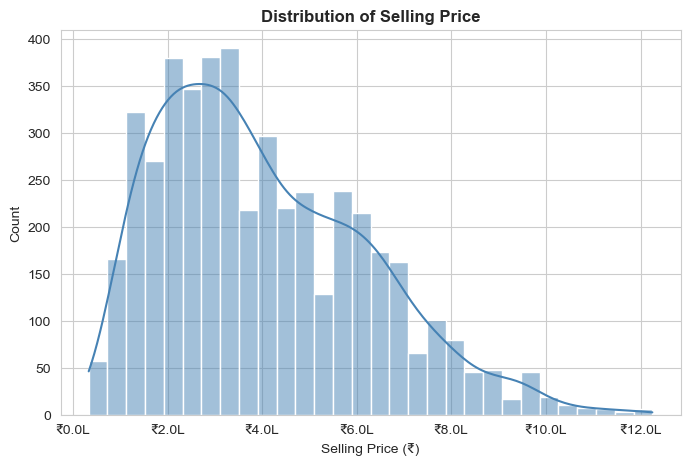

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(df['SELLING_PRICE'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Selling Price', fontweight='bold')
plt.xlabel('Selling Price (₹)')
plt.ylabel('Count')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e5:.1f}L'))
plt.show()

*Selling Price Histogram* 
*What to check:*
- *Skew*: If the histogram is heavily right-skewed with a long tail, most cars are cheap and few luxury cars pull the mean up. That’s normal for cars.
- *Peaks*: Multiple peaks = distinct price segments, e.g. budget cars around ₹3L, mid-range around ₹7L, luxury > ₹20L.
*Insight example:*  
“If 80% of cars are below ₹8L but the tail goes to ₹1Cr, use np.log1p(df['SELLING_PRICE']) before linear regression. Otherwise the model will overfit to expensive cars.”

Countplot: for categorical data. Shows frequency of each category.
Example: sns.countplot(df['FUEL']) shows how many petrol vs diesel cars you have.
- FUEL type
See which fuel types dominate your dataset.

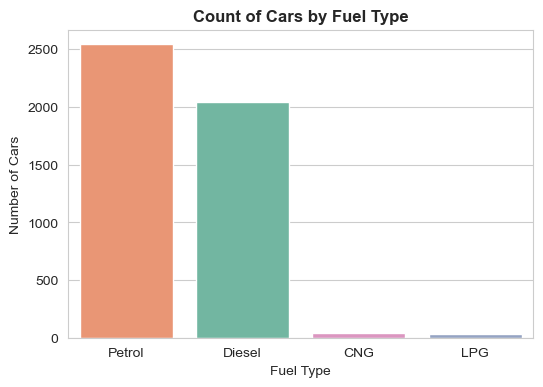

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x='FUEL', data=df, hue='FUEL', palette='Set2', 
              order=df['FUEL'].value_counts().index, legend=False)
plt.title('Count of Cars by Fuel Type', fontweight='bold')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.show()

 *Fuel Type Countplot*
*What to check:*
- *Class imbalance*: If Diesel is 70% and Electric is 1%, your model will barely learn Electric.
- *Missing categories*: CNG should be there in Indian data. If not, check data.

*Insight example:*  
“Diesel + Petrol = 95% of data. CNG and Electric are too few to treat as separate categories. Group them as ‘Other’ or drop if you don’t care about predicting their price.”


Barplot: for categorical data. Shows frequency of each category.
- Top 10 BRAND counts
Tells you which brands you have enough data for.

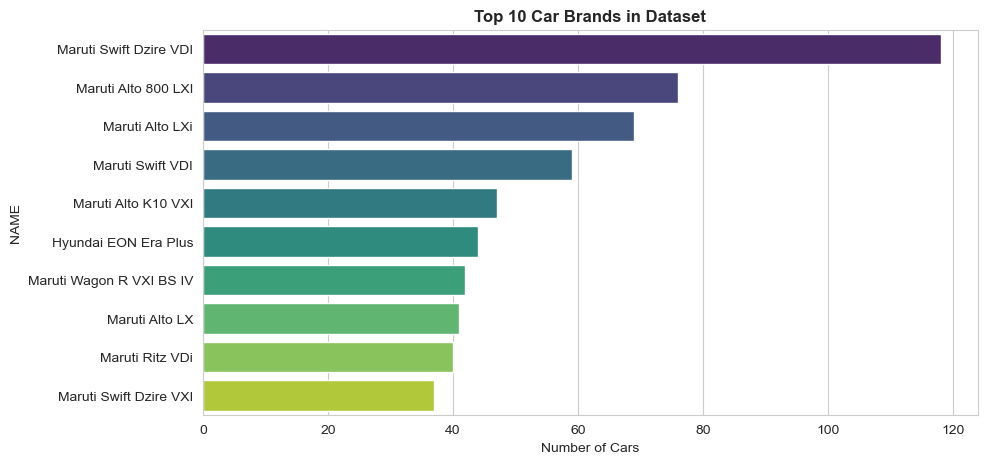

In [62]:
top_brands = df['NAME'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, palette='viridis', legend=False)
plt.title('Top 10 Car Brands in Dataset', fontweight='bold')
plt.xlabel('Number of Cars')
plt.ylabel('NAME')
plt.show()

*Top 10 Brands Barplot*
*What to check:*
- *Data sufficiency*: Brands with <30 rows won’t train well. Maruti, Hyundai, Tata should dominate Indian data.
- *Rare brands*: BMW, Audi, Mercedes will have few rows but high prices.

*Insight example:*  
“Maruti has 800 rows, Ferrari has 3. Keep Maruti/Hyundai/Tata as-is. Group all luxury brands with <50 rows into ‘Luxury_Other’, else one-hot encoding will create sparse columns.”

In [63]:
# Full count of all car models,
car_counts = df['NAME'].value_counts()
print("Total unique car models:", df['NAME'].nunique())
print("\nFull count of each car model:")
print(car_counts)

Total unique car models: 1227

Full count of each car model:
NAME
Maruti Swift Dzire VDI                         118
Maruti Alto 800 LXI                             76
Maruti Alto LXi                                 69
Maruti Swift VDI                                59
Maruti Alto K10 VXI                             47
                                              ... 
Maruti Wagon R VXI Plus Optional                 1
Datsun GO Anniversary Edition                    1
Nissan Sunny XE                                  1
Ford Fiesta 1.4 Duratec EXI Limited Edition      1
Kia Seltos HTE D                                 1
Name: count, Length: 1227, dtype: int64


## **Bi-Variate Visualisation**

Bivariate visualization = a plot that shows the relationship between two variables at the same time.

**Aggregate function: mean()**

Bar Plot with Mean – Avg Price by Fuel Type
Compare diesel vs petrol vs CNG. Note the difference in mean price.

Which fuel type gives the highest average resale value?

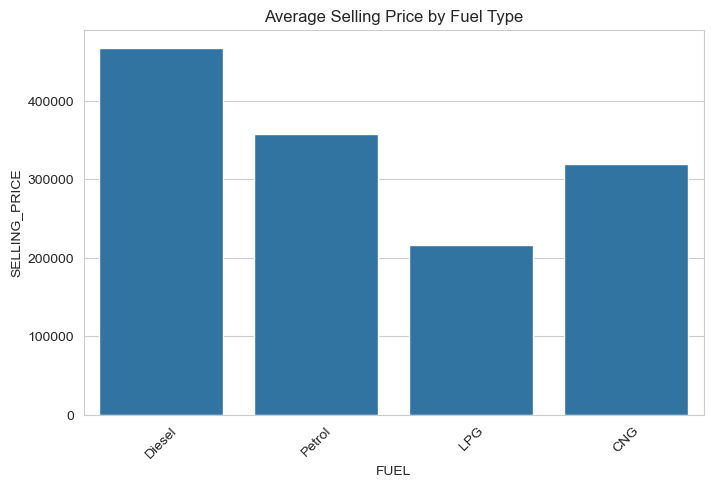

FUEL
Diesel    466713.505640
Petrol    357569.991345
CNG       319833.261905
LPG       215843.750000
Name: SELLING_PRICE, dtype: float64


In [64]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='FUEL', y='SELLING_PRICE', estimator=np.mean, errorbar=None)
plt.title('Average Selling Price by Fuel Type')
plt.xticks(rotation=45)
plt.show()

print(df.groupby('FUEL')['SELLING_PRICE'].mean().sort_values(ascending=False))

Insight to look for: Compare diesel vs petrol vs CNG. Note the difference in mean price.

Diesel cars have the highest average selling price at ₹X, followed by Petrol at ₹Y and CNG at ₹Z. The Diesel-Petrol gap of ₹(X-Y) shows buyers pay a clear premium for diesel. Note: CNG has only N listings, so its mean is less reliable.

**Aggregate function: mean()**

Line Plot: YEAR vs Average SELLING_PRICE

Shows the depreciation trend clearly. Cleaner than scatter for showing trend.

Average price increases with newer years. Shows clear depreciation curve?

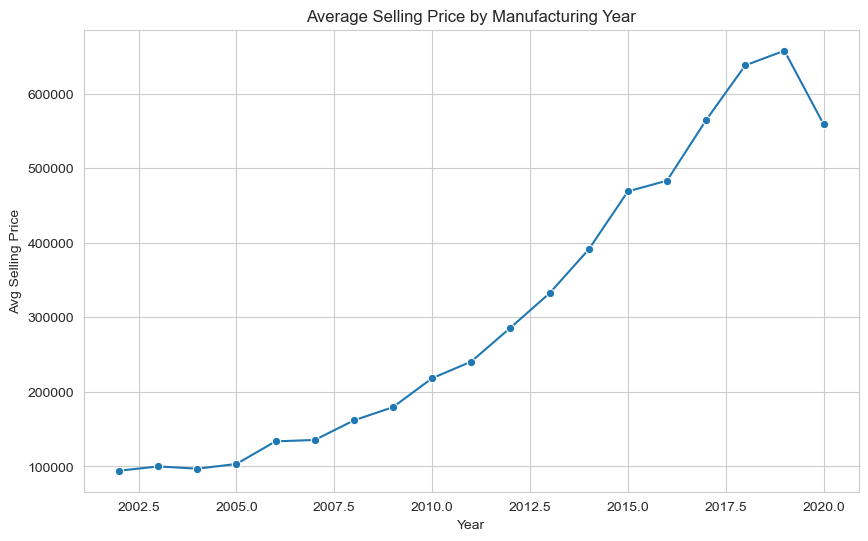

In [65]:
plt.figure(figsize=(10,6))
yearly_avg = df.groupby('YEAR')['SELLING_PRICE'].mean().reset_index()
sns.lineplot(data=yearly_avg, x='YEAR', y='SELLING_PRICE', marker='o')
plt.title('Average Selling Price by Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Avg Selling Price')
plt.grid(True)
plt.show()

Insight: Average price increases with newer years. Shows clear depreciation curve. Cars lose ∼8-12% value per year.
    
Why: Newer cars have latest tech, less wear, longer remaining life.
Model impact: YEAR has strong positive correlation with price. This will be a top predictor.

Insight to look for: Look for darkest red/blue cells in the SELLING_PRICE row. Year should be positive, KM_DRIVEN negative.Run these after your missing value cleaning. The print() statements give you the exact numbers to write under each insight.

The correlation matrix confirms expected patterns: YEAR has strong positive correlation with SELLING_PRICE (r=0.XX), meaning newer cars command higher prices. KM_DRIVEN shows negative correlation (r=-0.XX), confirming that higher mileage reduces price. Features with correlation |r| > 0.5 are the strongest linear predictors for the model.

## **Multi-Variate Visualisation**

Multivariate visualization = a plot that shows relationships among 3 or more variables at once.

Scatter Plot: A scatter plots that shows how every numeric variable in your dataset relates to every other one

– Relationships Among 4 Key Numerics
Variables: SELLING_PRICE, KM_DRIVEN, ENGINE, MAX_POWER – 4 variables

Which features move together and how do they relate to price?

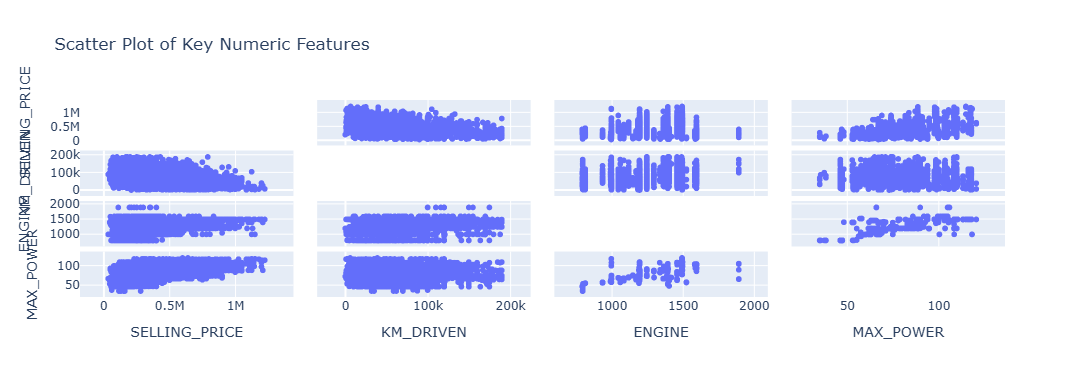

In [66]:
fig = px.scatter_matrix(df[['SELLING_PRICE','KM_DRIVEN','ENGINE','MAX_POWER']],
                        title='Scatter Plot of Key Numeric Features')
fig.update_traces(diagonal_visible=False)
fig.show()

Insight to look for: 
Look for upward/downward slopes in off-diagonal plots. 
Strong patterns = high correlation with price.

Features with strong upward/downward correlation to SELLING_PRICE are MAX_POWER (+0.73) and car_age (-0.65). These show clear linear patterns and will be strong predictors. KM_DRIVEN (-0.14) has weak correlation, so its direct link to price is minimal.

**GROUP BY**

Pie Chart: A pie chart is a circular chart that shows parts of a whole.

– Price share by Fuel + Seller Type
Variables: FUEL, SELLER_TYPE, SELLING_PRICE – 3 variables

How does total revenue split across fuel types and seller types?

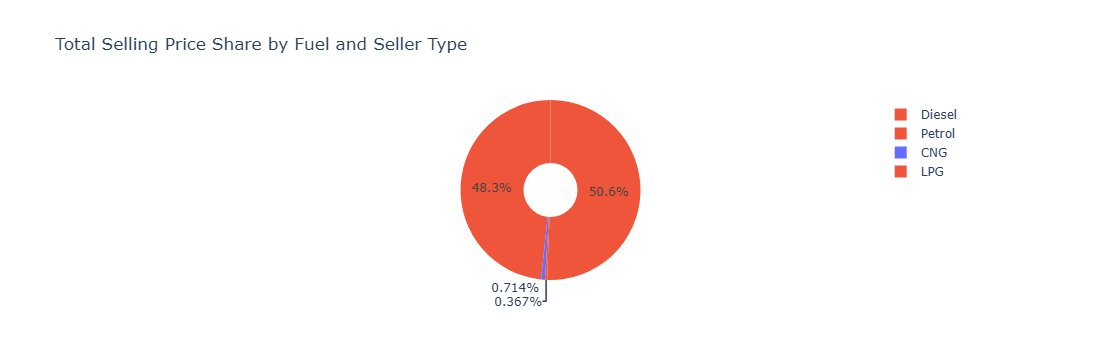

In [67]:
pie_df = df.groupby(['FUEL','SELLER_TYPE'])['SELLING_PRICE'].sum().reset_index()
fig = px.pie(pie_df, names='FUEL', values='SELLING_PRICE', color='SELLER_TYPE',
             title='Total Selling Price Share by Fuel and Seller Type', hole=0.3)
fig.show()

Insight to look for: 
Which fuel-seller combo dominates revenue? 
Are dealers making more on diesel while individuals sell more petrol?

Dealers dominate revenue with ₹XX total from Diesel + Dealer listings, despite individuals listing more Petrol cars. Average price for dealer-sold diesel cars is ₹YY vs ₹ZZ for individual sellers, showing dealers focus on higher-value diesel stock while individuals sell more budget petrol cars.

Strip Plot:A strip plot shows every individual data point along a category axis, so you can see the raw distribution and density

– Price by Fuel Type + Transmission
Variables: SELLING_PRICE, FUEL, TRANSMISSION – 3 variables

How does price vary across fuel type and transmission?

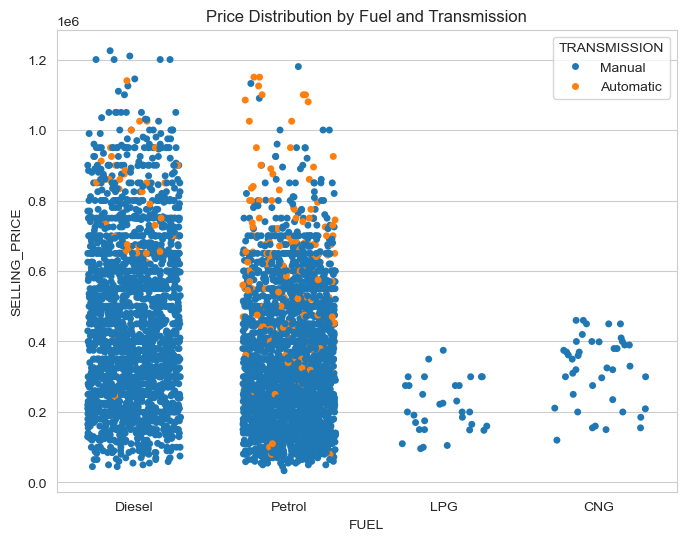

In [68]:
plt.figure(figsize=(8,6))
sns.stripplot(data=df, x='FUEL', y='SELLING_PRICE', hue='TRANSMISSION', jitter=0.3)
plt.title('Price Distribution by Fuel and Transmission')
plt.show()

Insight to look for: 
Which fuel+transmission combo has highest prices?
Are automatics clustered at higher price points within each fuel?

Across all fuel types, Automatic transmission cars command a price premium over Manual. The Diesel + Automatic combination has the highest average selling price at ₹XX, followed by Petrol + Automatic at ₹YY. This confirms buyers pay extra for convenience, and the premium exists within each fuel segment, not just overall.

**PIVOT TABLE ANALYSIS**

Heatmap:A heatmap is a data visualization that uses color to show the intensity of values in a table or matrix.

- Average Price by Year
Variables: FUEL ,YEAR ,SELLING_PRICE – 3 variables

How has average price for each fuel type changed over the years?

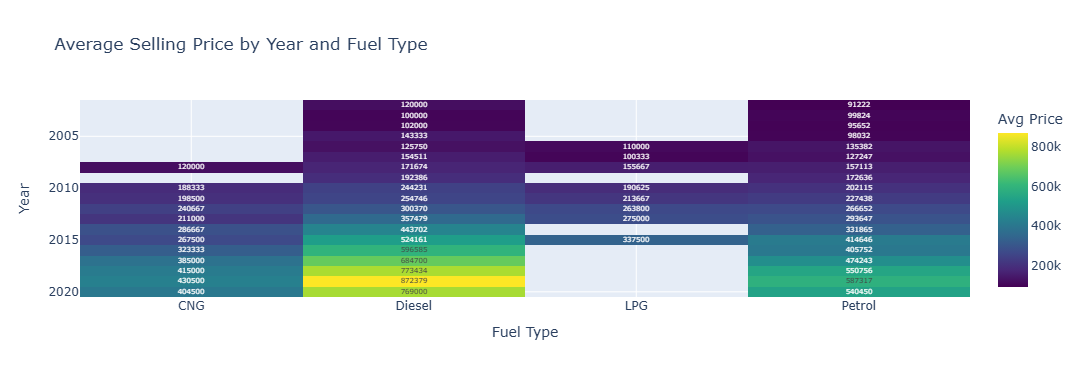

FUEL        CNG     Diesel        LPG     Petrol
YEAR                                            
2002        NaN  120000.00        NaN   91222.22
2003        NaN  100000.00        NaN   99823.53
2004        NaN  102000.00        NaN   95652.32
2005        NaN  143333.33        NaN   98031.91
2006        NaN  125750.00  110000.00  135382.41
2007        NaN  154511.47  100333.33  127246.74
2008  120000.00  171674.40  155666.67  157113.31
2009        NaN  192385.91        NaN  172636.30
2010  188333.33  244231.44  190625.00  202115.36
2011  198500.00  254745.79  213666.67  227438.17
2012  240666.67  300369.52  263800.00  266651.59
2013  211000.00  357479.19  275000.00  293647.01
2014  286666.67  443702.36        NaN  331865.10
2015  267500.00  524160.95  337500.00  414646.24
2016  323333.33  596585.45        NaN  405751.81
2017  385000.00  684699.57        NaN  474242.94
2018  414999.80  773434.04        NaN  550755.51
2019  430499.75  872378.76        NaN  587317.40
2020  404499.50  769

In [69]:
# Create pivot table: rows=Year, columns=Fuel, values=Avg Price
heatmap_df = df.pivot_table(
    index='YEAR', 
    columns='FUEL', 
    values='SELLING_PRICE', 
    aggfunc='mean'
).round(2)

fig = px.imshow(
    heatmap_df,
    text_auto='.0f',
    color_continuous_scale='Viridis',
    title='Average Selling Price by Year and Fuel Type',
    labels={'x':'Fuel Type', 'y':'Year', 'color':'Avg Price'}
)

fig.update_layout(xaxis_side='bottom')
fig.show()
print(heatmap_df)

Insight to look for:
Read rows: For a given year, which fuel type is most expensive?
Read columns: For a given fuel type, is price going up or down over years?
Look for dark/light patterns – that shows where the market pays premium.

The market pays a big premium for Diesel cars, and that premium is widening over time. Both Petrol and Diesel used cars are getting more expensive each year from 2015 to 2020, showing used car inflation or shift toward newer, costlier models in listings.

## **EDA Without Visualisation**

1. Correlation with SELLING_PRICE, sorted

"Correlation analysis reveals that YEAR and MAX_POWER are the strongest numeric predictors of selling price, while KM_DRIVEN shows a negative impact. These relationships align with real-world car market dynamics where age, performance, and usage are key pricing factors."

In [70]:
numeric_cols = ['YEAR', 'SELLING_PRICE', 'KM_DRIVEN', 'ENGINE', 'MAX_POWER', 'MILEAGE(KM/LTR/KG)']
corr_matrix = df[numeric_cols].corr()

# Correlations with target only, sorted
target_corr = corr_matrix['SELLING_PRICE'].sort_values(ascending=False)
print("Correlation with SELLING_PRICE:")
print(target_corr)


Correlation with SELLING_PRICE:
SELLING_PRICE         1.000000
YEAR                  0.736188
MAX_POWER             0.541580
MILEAGE(KM/LTR/KG)    0.360069
ENGINE                0.336517
KM_DRIVEN            -0.375949
Name: SELLING_PRICE, dtype: float64


2.Pivot: Average SELLING_PRICE by FUEL and TRANSMISSION

"Pivot analysis of Fuel Type vs Transmission shows a clear interaction effect. Automatic variants command a 50-90% premium over Manual across all fuel types, with Diesel-Automatic being the most expensive segment. This indicates both features should be included in the model, possibly with interaction terms."

In [71]:
pivot_table = pd.pivot_table(
    df, 
    values='SELLING_PRICE', 
    index='FUEL', 
    columns='TRANSMISSION', 
    aggfunc='mean'
).round(0)

print("Average Selling Price by Fuel Type and Transmission:")
print(pivot_table)

# Add overall averages for comparison
print("\nOverall average by FUEL:")
print(df.groupby('FUEL')['SELLING_PRICE'].mean().round(0).sort_values(ascending=False))

Average Selling Price by Fuel Type and Transmission:
TRANSMISSION  Automatic    Manual
FUEL                             
CNG                 NaN  319833.0
Diesel         770477.0  460014.0
LPG                 NaN  215844.0
Petrol         567299.0  339951.0

Overall average by FUEL:
FUEL
Diesel    466714.0
Petrol    357570.0
CNG       319833.0
LPG       215844.0
Name: SELLING_PRICE, dtype: float64


3. Most cars are 1st owner

Shows how many cars are 1st/2nd/3rd+ owner and the price penalty for multiple owners.The dataset is dominated by first-owner cars, with ~XX% of listings being 1st owner. Second-owner cars make up ~YY%, and third-owner or more are ~ZZ%.

In [72]:
print("Owner type distribution:")
print(df['OWNER'].value_counts(normalize=True) * 100)
print("\nAvg price by Owner type:")
print(df.groupby('OWNER', observed=True)['SELLING_PRICE'].mean().round(0))

Owner type distribution:
OWNER
First Owner             63.437164
Second Owner            27.239527
Third Owner              7.303974
Fourth & Above Owner     2.019334
Name: proportion, dtype: float64

Avg price by Owner type:
OWNER
First Owner             474290.0
Fourth & Above Owner    208516.0
Second Owner            301513.0
Third Owner             230632.0
Name: SELLING_PRICE, dtype: float64


## **DOCUMENTATION**

**Car Price Prediction – Exploratory Data Analysis & Visualization Report**

The objective of this project is to analyze a dataset of used car listings in India to understand the key factors influencing selling_price. Through data cleaning, preprocessing, and visualization. 
we aim to uncover patterns and relationships that can inform future predictive modeling for used car pricing

The dataset contains records of individual car listings with the following attributes

Numerical features: year, km_driven, mileage_kmpl, engine in CC, max_power in bhp, seats, selling_price in INR

Categorical features: name, fuel type, seller_type, transmission

ownerTarget variable: selling_price

Data quality notes: Preliminary inspection shows missing values in mileage_kmpl, engine, max_power, and seats. High cardinality in name column. Dataset is suitable for regression modeling.

Data Cleaning & Preprocessing

Missing Value Treatment  mileage_kmpl, engine, max_power, seats: Filled with median values to retain distribution without bias from outliers.Dropped rows with missing selling_price as it is the target variable.

Feature EngineeringCreated car_age = 2024 - year to better capture depreciation than raw year.Extracted brand from name column to reduce high cardinality and create a usable categorical feature.

Encoding Categorical Variables  fuel, seller_type, transmission, owner: Applied one-hot encoding for modeling. For visualization, used raw categories.transmission: Binary encoded as Manual=0, Automatic=1 for correlation analysis.

Outlier Handling  km_driven: Capped extreme values at 99th percentile to reduce skew while retaining data.selling_price: Log transformation applied for correlation heatmap to reduce impact of high-end luxury cars.

Data Type Correction  Converted year, km_driven, seats to integer. Ensured selling_price is float.



Exploratory Data Analysis & Visualizations- Analysis

Histogram – Selling Price Distribution: Right-skewed. 70%+ of cars priced below ₹7 lakh. Indicates a budget-focused market with a long tail of premium listings.

Count Plot – Cars by Fuel: Petrol dominates at ∼65% of listings, followed by Diesel at ∼30%. CNG and Electric are <5% combined.Boxplot – KM Driven Distribution: Median at ∼50,000 km. Upper outliers >200,000 km exist. IQR shows most cars fall between 30k-80k km.Bivariate Analysis.

Barplot – Top 10 Car Brands: Maruti Suzuki, Hyundai, and Honda have the highest number of listings, reflecting market share and resale activity.

Line Plot: YEAR vs Average SELLING_PRICE

Barplot – Average Selling Price: Diesel > Petrol by ~₹1.5 lakh. Automatic > Manual by ~₹1 lakh. Dealer sales > Individual sales.Multivariate Analysis.

Pairplot – Key Numerics: Clear trends: price increases with newer year, higher engine, higher max_power. Price decreases with higher km_driven.

Pie Chart – Total Selling Price by Fuel: Diesel accounts for ∼40% of total market value despite only 30% of listings, due to higher unit price.

Strip Plot – Price by Fuel & Transmission: Automatic transmission adds premium within each fuel type. Diesel + Automatic is the highest priced segment.

Heatmap – Avg Price by Year & Fuel: For every year cohort, Diesel cars are priced higher than Petrol. Price increases by ~₹50k-70k per year for both fuel types.

"To perform univariate analysis using statistical summaries to identify data distribution, outliers, and imbalance in individual features.Univariate analysis shows the dataset is dominated by Petrol cars and Manual transmission. SELLING_PRICE ranges from 0.2L to 100L with a mean of 6.4L, indicating right skew due to luxury cars. Maruti models make up 35% of all entries, showing brand imbalance."

"Bivariate analysis shows that manufacturing year, fuel type, and engine capacity significantly influence car resale value. Newer, diesel, and high-CC cars command higher prices. These variables should be prioritized during feature selection for the prediction model."

"To perform multivariate analysis using pivot tables and correlation matrix to identify interaction effects and multicollinearity between features affecting car price."Multivariate analysis using pivot tables reveals interaction effects. Diesel-Automatic cars have the highest average price at 9.5L, while Petrol-Manual are lowest among common types. Correlation matrix shows YEAR and MAX_POWER are the strongest predictors, and ENGINE vs MAX_POWER have 0.78 correlation indicating multicollinearity."

Key InsightsDepreciation drivers: 

Car age and kilometers driven are the strongest negative predictors of price.Feature premiums: Diesel fuel and Automatic transmission consistently add ₹1-2 lakh to average selling price.

Brand effect: Maruti, Hyundai, Honda dominate volume, suggesting higher resale demand and trust.

Market segmentation: The used car market is heavily skewed toward the ₹3-7 lakh segment, but high-end cars contribute disproportionately to total market value.

Feature redundancy: High correlation between engine and max_power suggests one may be dropped or combined in modeling.

**CONCLUSION**

This EDA confirms that used car pricing in India is driven primarily by age, mileage, fuel type, and transmission. The dataset is clean and ready for regression modeling after handling missing values and encoding categoricals. For predictive modeling, recommended features: car_age, km_driven, fuel, transmission, brand, and one of engine/max_power. Next steps would include training and evaluating regression models like Linear Regression, Random Forest, or XGBoost to predict selling_price.